# 🕳️ Complete Guide to Handling Missing Values in Data Science

**A Beginner-Friendly Notebook for Data Wrangling & Preprocessing**

---

## 📚 What You'll Learn:
1. What are missing values and why they matter
2. Types of missing data (MCAR, MAR, MNAR)
3. How to detect missing values
4. Impact on Machine Learning models
5. Strategies to handle missing values
6. Best practices and prevention

**Let's dive in! 🚀**

In [1]:
# 📦 Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🤔 What are Missing Values?

Missing values are **empty or null entries** in your dataset where data should exist but doesn't.

### Common Representations:
- `NaN` (Not a Number) - Most common in Python/Pandas
- `None` - Python null value
- `NULL` or `NA` - Common in databases
- Empty strings `""` or `''`
- Special codes like `-999`, `?`, `N/A`

### Why Do Missing Values Occur?
1. **Data Entry Errors**: Human mistakes during input
2. **Equipment Failure**: Sensors malfunctioning
3. **Survey Non-Response**: People skip questions
4. **Data Integration**: Merging datasets with different structures
5. **Privacy Concerns**: Sensitive information removed
6. **Time Constraints**: Data not yet available

In [2]:
# 🎨 Creating a realistic sample dataset with missing values
# This simulates a health & wellness survey

np.random.seed(42)  # For reproducibility

n_samples = 200

data = {
    'person_id': range(1, n_samples + 1),
    'age': np.random.randint(18, 65, n_samples),
    'gender': np.random.choice(['M', 'F', 'Other'], n_samples),
    'daily_screen_time_min': np.random.normal(300, 100, n_samples).astype(int),
    'social_media_time_min': np.random.normal(120, 60, n_samples).astype(int),
    'sleep_hours': np.random.normal(7, 1.5, n_samples).round(1),
    'physical_activity_min': np.random.normal(45, 30, n_samples).astype(int),
    'stress_level': np.random.randint(1, 11, n_samples),
    'anxiety_level': np.random.randint(1, 11, n_samples),
    'income_bracket': np.random.choice(['Low', 'Medium', 'High', np.nan], n_samples, p=[0.3, 0.4, 0.2, 0.1])
}

df = pd.DataFrame(data)

# 🎯 Now let's introduce missing values strategically to demonstrate different types

# 1. MCAR: Completely random missing (5% of sleep data)
mcar_indices = np.random.choice(df.index, size=int(0.05 * len(df)), replace=False)
df.loc[mcar_indices, 'sleep_hours'] = np.nan

# 2. MAR: Missing related to observed data (older people less likely to report activity)
older_people = df[df['age'] > 50].index
mar_indices = np.random.choice(older_people, size=int(0.3 * len(older_people)), replace=False)
df.loc[mar_indices, 'physical_activity_min'] = np.nan

# 3. MNAR: Missing related to value itself (high stress people avoid reporting)
high_stress = df[df['stress_level'] > 7].index
df.loc[high_stress, 'anxiety_level'] = np.nan

# 4. Some completely empty rows (simulating dropouts)
dropout_indices = np.random.choice(df.index, size=5, replace=False)
df.loc[dropout_indices, ['daily_screen_time_min', 'social_media_time_min']] = np.nan

print("✅ Sample dataset created with strategic missing values!")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

✅ Sample dataset created with strategic missing values!
Dataset shape: (200, 10)

First 5 rows:


,person_id,age,gender,daily_screen_time_min,social_media_time_min,sleep_hours,physical_activity_min,stress_level,anxiety_level,income_bracket
0,1,56,F,296.0,132.0,10.8,-2.0,4,10.0,Low
1,2,46,Other,246.0,-10.0,7.8,47.0,5,8.0,Medium
2,3,32,F,121.0,90.0,6.1,29.0,4,2.0,Low
3,4,60,Other,335.0,200.0,6.8,NaN,4,6.0,nan
4,5,25,M,258.0,178.0,8.6,61.0,8,NaN,Medium


## 🧩 Types of Missing Data (Rubin's Classification)

Understanding WHY data is missing is crucial for choosing the right strategy!

### 1️⃣ MCAR: Missing Completely At Random
- **Definition**: Missingness has NO relationship with any data (observed or missing)
- **Example**: A survey respondent accidentally skips a question
- **Impact**: Least problematic, but reduces sample size
- **Test**: Little's MCAR test (advanced)

### 2️⃣ MAR: Missing At Random
- **Definition**: Missingness relates to OBSERVED data, not the missing values themselves
- **Example**: Older people less likely to report income (but age is known)
- **Impact**: Can be handled with proper imputation
- **Most Common**: ~70% of real-world missing data

### 3️⃣ MNAR: Missing Not At Random
- **Definition**: Missingness relates to the MISSING values themselves
- **Example**: People with high anxiety don't report their anxiety levels
- **Impact**: Most problematic, requires domain knowledge or specialized methods
- **Solution**: Sensitivity analysis, pattern-mixture models

In [3]:
# 🔍 STEP 1: DETECTING MISSING VALUES

print("=== BASIC MISSING VALUE DETECTION ===\n")

# Method 1: Basic info
print("1. Dataset Info:")
df.info()
print("\n" + "="*50 + "\n")

# Method 2: Check for null values (Boolean matrix)
print("2. Null Value Matrix (first 10 rows):")
print(df.isnull().head(10))
print("\n" + "="*50 + "\n")

# Method 3: Count missing values per column
print("3. Missing Values Count per Column:")
missing_count = df.isnull().sum()
print(missing_count)
print("\n" + "="*50 + "\n")

# Method 4: Percentage of missing values
print("4. Missing Values Percentage:")
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Percent': missing_percent.values
}).sort_values('Missing_Percent', ascending=False)

print(missing_df)
print("\n" + "="*50 + "\n")

# Method 5: Check for any missing values in dataset
print(f"5. Any missing values in dataset? {df.isnull().values.any()}")
print(f"   Total missing cells: {df.isnull().sum().sum()}")
print(f"   Total cells: {df.size}")
print(f"   Overall missing %: {(df.isnull().sum().sum() / df.size) * 100:.2f}%")

=== BASIC MISSING VALUE DETECTION ===

1. Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   person_id              200 non-null    int64  
 1   age                    200 non-null    int32  
 2   gender                 200 non-null    object 
 3   daily_screen_time_min  195 non-null    float64
 4   social_media_time_min  195 non-null    float64
 5   sleep_hours            190 non-null    float64
 6   physical_activity_min  182 non-null    float64
 7   stress_level           200 non-null    int32  
 8   anxiety_level          142 non-null    float64
 9   income_bracket         200 non-null    object 
dtypes: float64(5), int32(2), int64(1), object(2)
memory usage: 14.2+ KB


2. Null Value Matrix (first 10 rows):
   person_id    age  gender  daily_screen_time_min  social_media_time_min  \
0      False  False   Fal

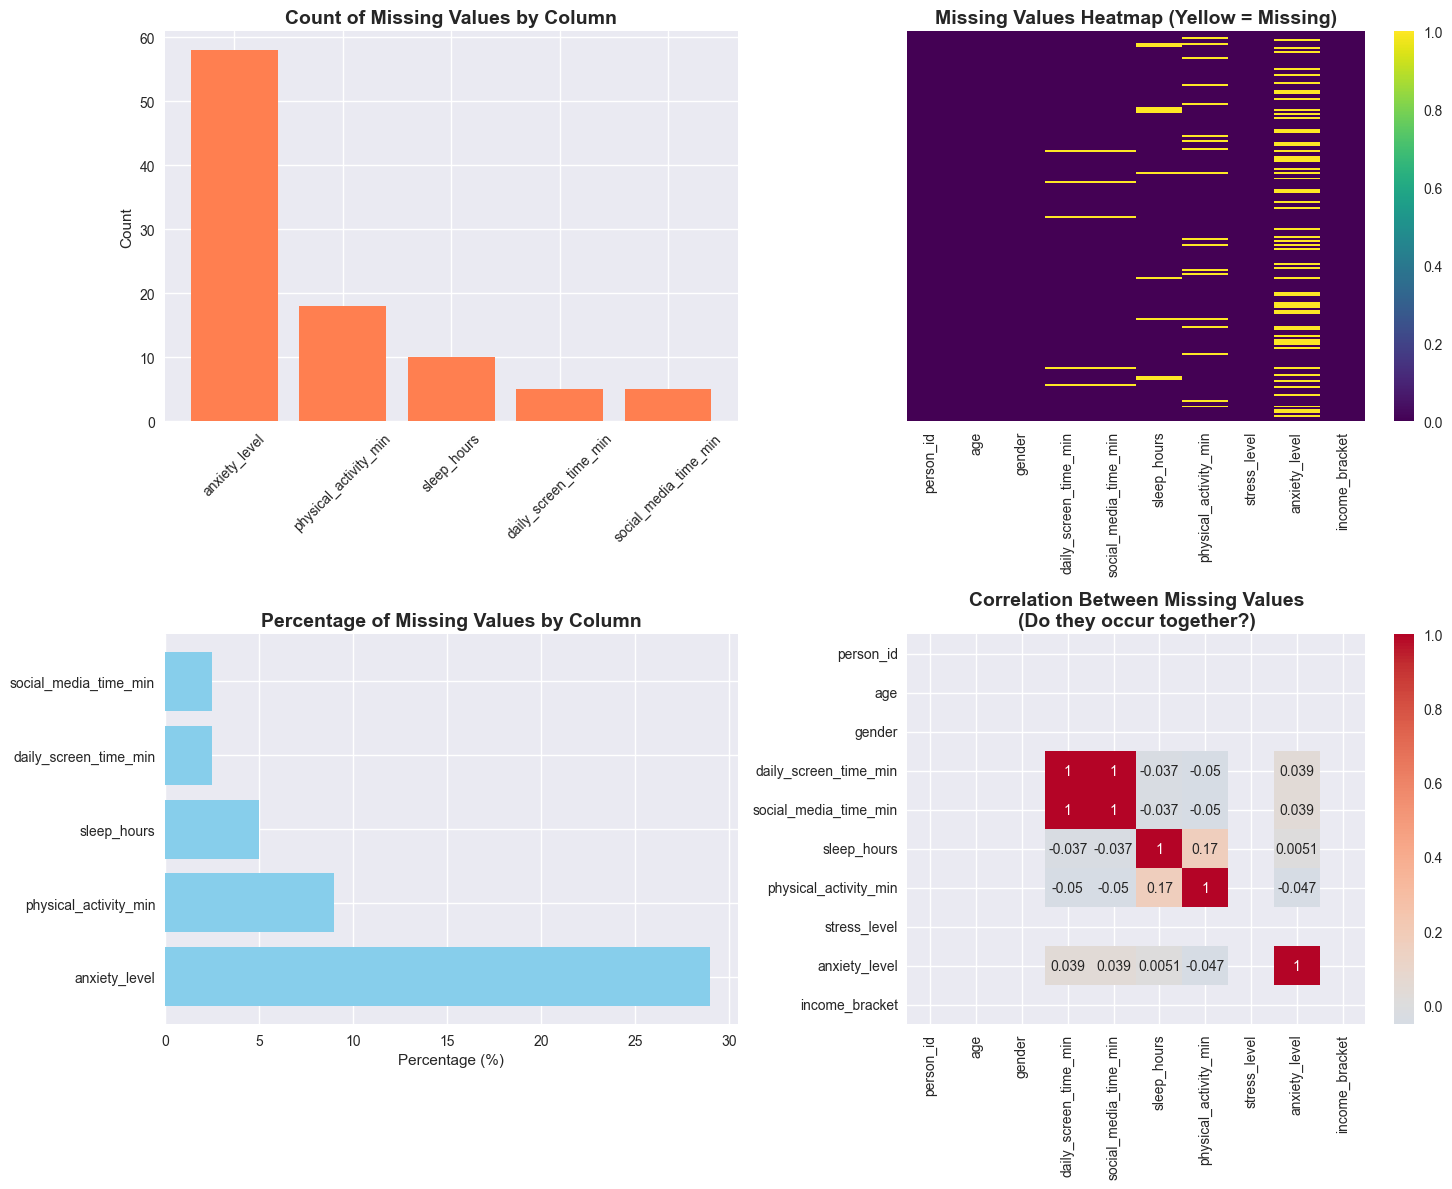


💡 Interpretation Tips:
- If two columns have high missing correlation, they might be missing together (systematic issue)
- Columns with >50% missing might need to be dropped
- Random scattered missing values are easier to handle than patterned ones


In [4]:
# 📊 STEP 2: VISUALIZING MISSING VALUES

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Bar chart of missing values
missing_df_plot = missing_df[missing_df['Missing_Count'] > 0]
axes[0, 0].bar(missing_df_plot['Column'], missing_df_plot['Missing_Count'], color='coral')
axes[0, 0].set_title('Count of Missing Values by Column', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Heatmap of missing values
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Missing Values Heatmap (Yellow = Missing)', fontsize=14, fontweight='bold')

# Plot 3: Percentage bar chart
axes[1, 0].barh(missing_df_plot['Column'], missing_df_plot['Missing_Percent'], color='skyblue')
axes[1, 0].set_title('Percentage of Missing Values by Column', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Percentage (%)')

# Plot 4: Missing value patterns (dendrogram style)
missing_corr = df.isnull().corr()
sns.heatmap(missing_corr, annot=True, cmap='coolwarm', center=0, ax=axes[1, 1])
axes[1, 1].set_title('Correlation Between Missing Values\n(Do they occur together?)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Interpretation Tips:")
print("- If two columns have high missing correlation, they might be missing together (systematic issue)")
print("- Columns with >50% missing might need to be dropped")
print("- Random scattered missing values are easier to handle than patterned ones")

## ⚠️ Why Missing Values Are Dangerous for Machine Learning

### 🚨 Direct Problems:
1. **Algorithm Failure**: Most ML algorithms cannot handle NaN values
   - Linear Regression, Logistic Regression, SVM, Neural Networks will crash!
   - Tree-based models (Random Forest, XGBoost) can handle them but with limitations

2. **Biased Results**:
   - If missing data isn't random, your model learns biased patterns
   - Example: If high-income people don't report income, model underestimates income impact

3. **Reduced Statistical Power**:
   - Deleting rows = losing information
   - Small sample size = unreliable predictions

### 📉 Consequences:
| Issue | Impact |
|-------|--------|
| Biased coefficients | Wrong feature importance |
| Reduced accuracy | Poor model performance |
| Invalid conclusions | Bad business decisions |
| Overfitting | Model doesn't generalize |

### 🎯 Real-World Example:
A bank builds a loan default predictor. If people with bad credit history are more likely to skip the "previous defaults" question, the model might approve risky loans!

In [5]:
# 🗑️ STRATEGY 1: DELETION METHODS (Use with caution!)

print("=== DELETION STRATEGIES ===\n")

# Make a copy to preserve original data
df_deletion = df.copy()

print(f"Original dataset shape: {df_deletion.shape}")
print(f"Original missing values: {df_deletion.isnull().sum().sum()}\n")

# Method 1: Listwise Deletion (Drop rows with ANY missing values)
print("1. LISTWISE DELETION (Drop rows with any missing values)")
df_listwise = df_deletion.dropna()
print(f"   Shape after listwise deletion: {df_listwise.shape}")
print(f"   Rows removed: {len(df_deletion) - len(df_listwise)}")
print(f"   Data loss: {((len(df_deletion) - len(df_listwise))/len(df_deletion)*100):.1f}%\n")

# Method 2: Pairwise Deletion (Analysis-specific, keeps all possible data)
print("2. PAIRWISE DELETION (Use available data for each analysis)")
print(f"   Mean age (using all available): {df_deletion['age'].mean():.2f}")
print(f"   Mean sleep (using available): {df_deletion['sleep_hours'].mean():.2f}")
print(f"   ✓ Uses different sample sizes for different variables\n")

# Method 3: Dropping columns with too many missing values
print("3. COLUMN DELETION (Drop columns with >threshold% missing)")
threshold = 20  # 20%
cols_to_drop = missing_df[missing_df['Missing_Percent'] > threshold]['Column'].tolist()
print(f"   Columns to drop (>20% missing): {cols_to_drop}")
df_col_drop = df_deletion.drop(columns=cols_to_drop)
print(f"   Shape after column deletion: {df_col_drop.shape}\n")

# Method 4: Dropping rows where specific columns are missing
print("4. TARGETED ROW DELETION (Drop if 'stress_level' is missing)")
df_targeted = df_deletion.dropna(subset=['stress_level'])
print(f"   Shape after targeted deletion: {df_targeted.shape}")
print(f"   Rows removed: {len(df_deletion) - len(df_targeted)}\n")

print("⚠️ PROS & CONS OF DELETION:")
print("✅ Pros: Simple, no data manipulation, preserves data types")
print("❌ Cons: Data loss, biased if not MCAR, reduced statistical power")
print("💡 Best for: MCAR data, <5% missing, large datasets")

=== DELETION STRATEGIES ===

Original dataset shape: (200, 10)
Original missing values: 96

1. LISTWISE DELETION (Drop rows with any missing values)
   Shape after listwise deletion: (120, 10)
   Rows removed: 80
   Data loss: 40.0%

2. PAIRWISE DELETION (Use available data for each analysis)
   Mean age (using all available): 41.57
   Mean sleep (using available): 6.88
   ✓ Uses different sample sizes for different variables

3. COLUMN DELETION (Drop columns with >threshold% missing)
   Columns to drop (>20% missing): ['anxiety_level']
   Shape after column deletion: (200, 9)

4. TARGETED ROW DELETION (Drop if 'stress_level' is missing)
   Shape after targeted deletion: (200, 10)
   Rows removed: 0

⚠️ PROS & CONS OF DELETION:
✅ Pros: Simple, no data manipulation, preserves data types
❌ Cons: Data loss, biased if not MCAR, reduced statistical power
💡 Best for: MCAR data, <5% missing, large datasets


=== STATISTICAL IMPUTATION ===

BEFORE IMPUTATION:
Sleep hours - Mean: 6.88, Std: 1.59
Physical activity - Mean: 46.69, Std: 27.73

1. MEAN IMPUTATION (Best for: Normal distribution, no outliers)
   Filled 10 missing sleep hours with mean: 6.88

2. MEDIAN IMPUTATION (Best for: Skewed data, outliers present)
   Filled 18 missing activities with median: 47.00

3. MODE IMPUTATION (Best for: Categorical data)
   Filled 0 missing incomes with mode: Medium



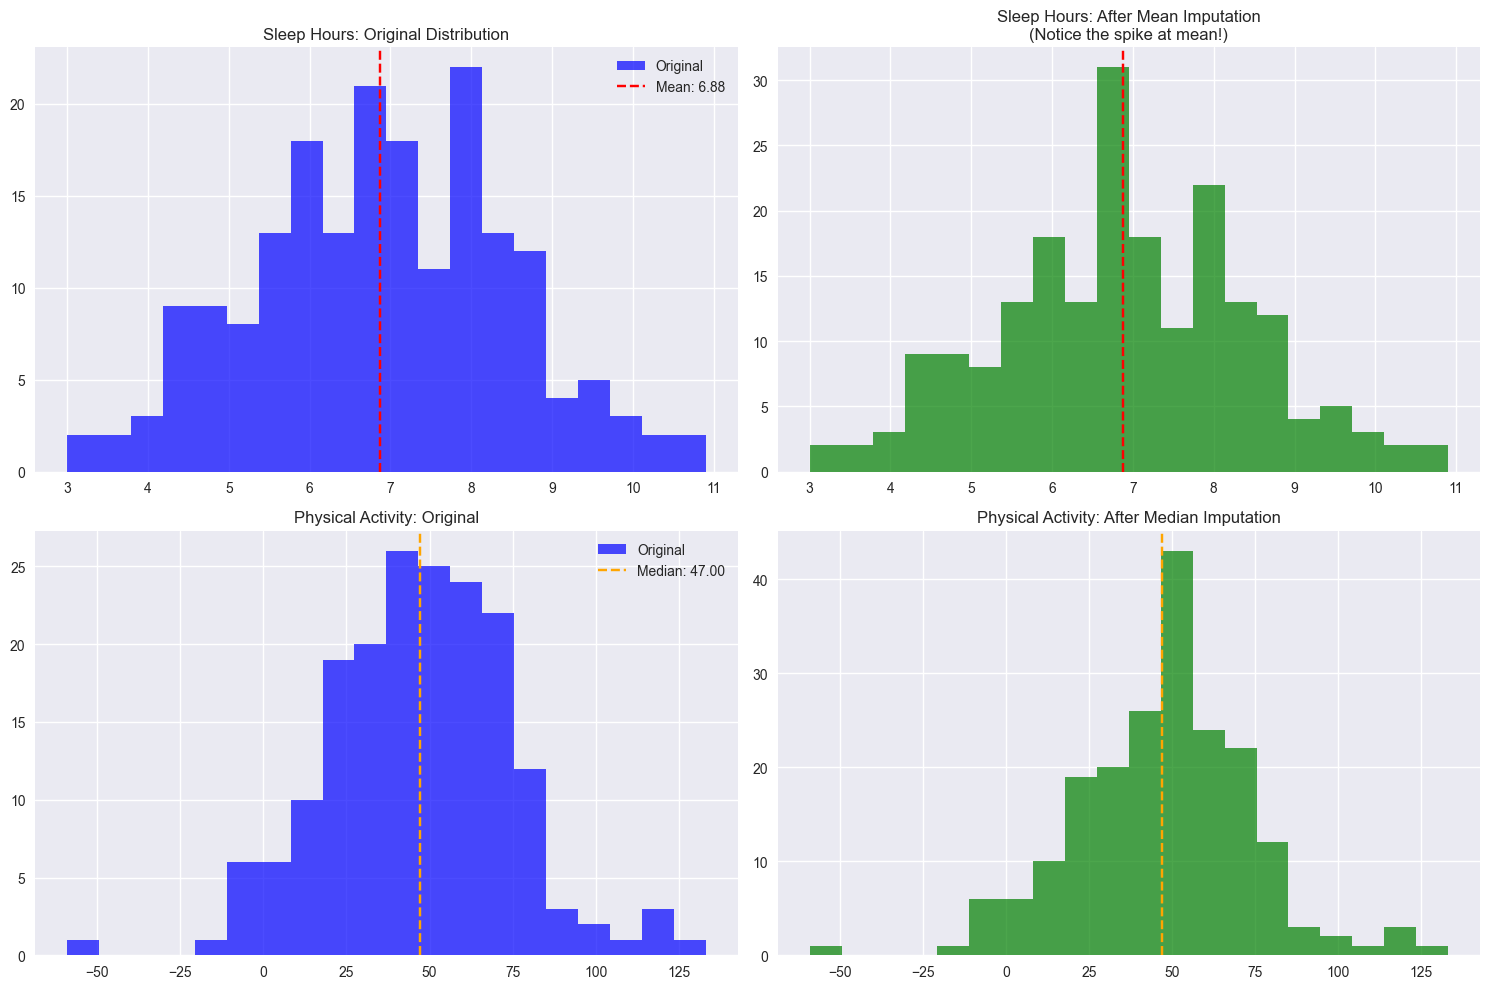


⚠️ PROS & CONS:
✅ Pros: Simple, fast, works with small datasets
❌ Cons: Reduces variance, distorts correlations, creates artificial spikes
💡 Best for: Quick analysis, small datasets, MCAR data


In [6]:
# 🎯 STRATEGY 2: STATISTICAL IMPUTATION (Mean/Median/Mode)

print("=== STATISTICAL IMPUTATION ===\n")

df_stat = df.copy()

# Before imputation stats
print("BEFORE IMPUTATION:")
print(f"Sleep hours - Mean: {df_stat['sleep_hours'].mean():.2f}, Std: {df_stat['sleep_hours'].std():.2f}")
print(f"Physical activity - Mean: {df_stat['physical_activity_min'].mean():.2f}, Std: {df_stat['physical_activity_min'].std():.2f}\n")

# Method 1: Mean Imputation (for normally distributed data)
print("1. MEAN IMPUTATION (Best for: Normal distribution, no outliers)")
sleep_mean = df_stat['sleep_hours'].mean()
df_stat['sleep_hours_mean'] = df_stat['sleep_hours'].fillna(sleep_mean)
print(f"   Filled {df_stat['sleep_hours'].isnull().sum()} missing sleep hours with mean: {sleep_mean:.2f}\n")

# Method 2: Median Imputation (for skewed data/outliers)
print("2. MEDIAN IMPUTATION (Best for: Skewed data, outliers present)")
activity_median = df_stat['physical_activity_min'].median()
df_stat['physical_activity_median'] = df_stat['physical_activity_min'].fillna(activity_median)
print(f"   Filled {df_stat['physical_activity_min'].isnull().sum()} missing activities with median: {activity_median:.2f}\n")

# Method 3: Mode Imputation (for categorical data)
print("3. MODE IMPUTATION (Best for: Categorical data)")
income_mode = df_stat['income_bracket'].mode()[0]
df_stat['income_mode'] = df_stat['income_bracket'].fillna(income_mode)
print(f"   Filled {df_stat['income_bracket'].isnull().sum()} missing incomes with mode: {income_mode}\n")

# Visualization comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sleep hours comparison
axes[0, 0].hist(df['sleep_hours'].dropna(), bins=20, alpha=0.7, label='Original', color='blue')
axes[0, 0].axvline(sleep_mean, color='red', linestyle='--', label=f'Mean: {sleep_mean:.2f}')
axes[0, 0].set_title('Sleep Hours: Original Distribution')
axes[0, 0].legend()

axes[0, 1].hist(df_stat['sleep_hours_mean'], bins=20, alpha=0.7, color='green')
axes[0, 1].axvline(sleep_mean, color='red', linestyle='--')
axes[0, 1].set_title('Sleep Hours: After Mean Imputation\n(Notice the spike at mean!)')

# Physical activity comparison
axes[1, 0].hist(df['physical_activity_min'].dropna(), bins=20, alpha=0.7, label='Original', color='blue')
axes[1, 0].axvline(activity_median, color='orange', linestyle='--', label=f'Median: {activity_median:.2f}')
axes[1, 0].set_title('Physical Activity: Original')
axes[1, 0].legend()

axes[1, 1].hist(df_stat['physical_activity_median'], bins=20, alpha=0.7, color='green')
axes[1, 1].axvline(activity_median, color='orange', linestyle='--')
axes[1, 1].set_title('Physical Activity: After Median Imputation')

plt.tight_layout()
plt.show()

print("\n⚠️ PROS & CONS:")
print("✅ Pros: Simple, fast, works with small datasets")
print("❌ Cons: Reduces variance, distorts correlations, creates artificial spikes")
print("💡 Best for: Quick analysis, small datasets, MCAR data")

In [7]:
# 🚀 STRATEGY 3: ADVANCED IMPUTATION TECHNIQUES

print("=== ADVANCED IMPUTATION METHODS ===\n")

# Prepare numeric data for advanced methods
numeric_cols = ['age', 'daily_screen_time_min', 'social_media_time_min', 
                'sleep_hours', 'physical_activity_min', 'stress_level', 'anxiety_level']
df_numeric = df[numeric_cols].copy()

print(f"Working with numeric columns: {numeric_cols}\n")

# Method 1: K-Nearest Neighbors (KNN) Imputation
print("1. KNN IMPUTATION (Uses similar rows to fill missing values)")
print("   Logic: Find 5 most similar rows and take average")
knn_imputer = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(
    knn_imputer.fit_transform(df_numeric),
    columns=numeric_cols
)
print(f"   ✓ Completed! Sample imputed values:")
print(f"   Sleep hours[0]: {df_knn.loc[0, 'sleep_hours']:.2f}")
print(f"   Physical activity[10]: {df_knn.loc[10, 'physical_activity_min']:.2f}\n")

# Method 2: Iterative Imputation (MICE - Multivariate Imputation)
print("2. ITERATIVE IMPUTATION (MICE - Models each feature from others)")
print("   Logic: Treats each feature as target, others as predictors")
iterative_imputer = IterativeImputer(random_state=42, max_iter=10)
df_iterative = pd.DataFrame(
    iterative_imputer.fit_transform(df_numeric),
    columns=numeric_cols
)
print(f"   ✓ Completed! Sample imputed values:")
print(f"   Sleep hours[0]: {df_iterative.loc[0, 'sleep_hours']:.2f}")
print(f"   Anxiety level[50]: {df_iterative.loc[50, 'anxiety_level']:.2f}\n")

# Method 3: Forward/Backward Fill (Time series specific)
print("3. FORWARD/BACKWARD FILL (For time-series data)")
df_time = df.copy().sort_values('age')  # Simulating time order
df_time['sleep_ffill'] = df_time['sleep_hours'].fillna(method='ffill')  # Forward
df_time['sleep_bfill'] = df_time['sleep_hours'].fillna(method='bfill')  # Backward
print(f"   Forward fill: {df_time['sleep_ffill'].isnull().sum()} missing remaining")
print(f"   Backward fill: {df_time['sleep_bfill'].isnull().sum()} missing remaining\n")

# Method 4: Constant/Arbitrary Value Imputation
print("4. CONSTANT IMPUTATION (For specific business logic)")
df_constant = df.copy()
df_constant['physical_activity_min'] = df_constant['physical_activity_min'].fillna(0)  # Assume no activity
df_constant['income_bracket'] = df_constant['income_bracket'].fillna('Unknown')
print(f"   Filled physical activity with 0 (assumption: no activity reported = 0)")
print(f"   Filled income with 'Unknown' category\n")

print("⚠️ PROS & CONS OF ADVANCED METHODS:")
print("✅ Pros: Preserves relationships, more accurate, handles complex patterns")
print("❌ Cons: Computationally expensive, risk of overfitting")
print("💡 Best for: MAR data, complex datasets, production models")

=== ADVANCED IMPUTATION METHODS ===

Working with numeric columns: ['age', 'daily_screen_time_min', 'social_media_time_min', 'sleep_hours', 'physical_activity_min', 'stress_level', 'anxiety_level']

1. KNN IMPUTATION (Uses similar rows to fill missing values)
   Logic: Find 5 most similar rows and take average
   ✓ Completed! Sample imputed values:
   Sleep hours[0]: 10.80
   Physical activity[10]: 68.00

2. ITERATIVE IMPUTATION (MICE - Models each feature from others)
   Logic: Treats each feature as target, others as predictors
   ✓ Completed! Sample imputed values:
   Sleep hours[0]: 10.80
   Anxiety level[50]: 5.64

3. FORWARD/BACKWARD FILL (For time-series data)
   Forward fill: 0 missing remaining
   Backward fill: 0 missing remaining

4. CONSTANT IMPUTATION (For specific business logic)
   Filled physical activity with 0 (assumption: no activity reported = 0)
   Filled income with 'Unknown' category

⚠️ PROS & CONS OF ADVANCED METHODS:
✅ Pros: Preserves relationships, more accur

In [8]:
# 🎓 STRATEGY 4: DOMAIN-SPECIFIC & BUSINESS LOGIC IMPUTATION

print("=== DOMAIN-SPECIFIC IMPUTATION ===\n")

df_domain = df.copy()

# Strategy 1: Group-based imputation (stratified by category)
print("1. GROUP-BASED IMPUTATION (By gender)")
print("   Logic: Men and women might have different average sleep patterns")

# Calculate mean sleep by gender
gender_sleep_mean = df_domain.groupby('gender')['sleep_hours'].transform('mean')
df_domain['sleep_by_gender'] = df_domain['sleep_hours'].fillna(gender_sleep_mean)

print("   Mean sleep by gender:")
print(df_domain.groupby('gender')['sleep_hours'].mean())
print()

# Strategy 2: Multiple column logic
print("2. DERIVED IMPUTATION (Calculate from other columns)")
print("   Logic: Social media time cannot exceed total screen time")

# If social media > screen time, or social media is missing but screen time exists
mask = df_domain['social_media_time_min'].isnull() & df_domain['daily_screen_time_min'].notnull()
df_domain.loc[mask, 'social_media_time_min'] = df_domain.loc[mask, 'daily_screen_time_min'] * 0.4
print(f"   Filled {mask.sum()} values as 40% of screen time\n")

# Strategy 3: Indicator variable approach (Don't lose the missing info!)
print("3. MISSING INDICATOR APPROACH (Keep track of what was missing)")
df_domain['sleep_missing'] = df_domain['sleep_hours'].isnull().astype(int)
df_domain['sleep_imputed'] = df_domain['sleep_hours'].fillna(df_domain['sleep_hours'].median())
print(f"   Created 'sleep_missing' indicator (1=was missing, 0=was present)")
print(f"   This helps model learn if missingness itself is predictive!\n")

# Strategy 4: End of tail imputation (for outliers)
print("4. END-OF-TAIL IMPUTATION (For extreme values)")
print("   Logic: Missing might mean 'extremely high' or 'extremely low'")
q99 = df_domain['stress_level'].quantile(0.99)
df_domain['stress_extreme'] = df_domain['stress_level'].fillna(q99)
print(f"   Filled missing stress with 99th percentile: {q99}\n")

print("💡 DOMAIN TIPS:")
print("- Always consult subject matter experts")
print("- Use business rules when available")
print("- Missing indicators can be powerful features!")
print("- Document your assumptions!")

=== DOMAIN-SPECIFIC IMPUTATION ===

1. GROUP-BASED IMPUTATION (By gender)
   Logic: Men and women might have different average sleep patterns
   Mean sleep by gender:
gender
F        6.935937
M        6.839344
Other    6.852308
Name: sleep_hours, dtype: float64

2. DERIVED IMPUTATION (Calculate from other columns)
   Logic: Social media time cannot exceed total screen time
   Filled 0 values as 40% of screen time

3. MISSING INDICATOR APPROACH (Keep track of what was missing)
   Created 'sleep_missing' indicator (1=was missing, 0=was present)
   This helps model learn if missingness itself is predictive!

4. END-OF-TAIL IMPUTATION (For extreme values)
   Logic: Missing might mean 'extremely high' or 'extremely low'
   Filled missing stress with 99th percentile: 10.0

💡 DOMAIN TIPS:
- Always consult subject matter experts
- Use business rules when available
- Missing indicators can be powerful features!
- Document your assumptions!


=== METHOD COMPARISON DEMONSTRATION ===

Analyzing index 6 (original value: nan):

Imputed Values Comparison:
         Method  Imputed_Value  Difference_from_Mean
0          Mean           6.88                  0.00
1        Median           6.90                  0.02
2           KNN           5.88                 -1.00
3     Iterative           6.96                  0.09
4  Gender-Group           6.84                 -0.04



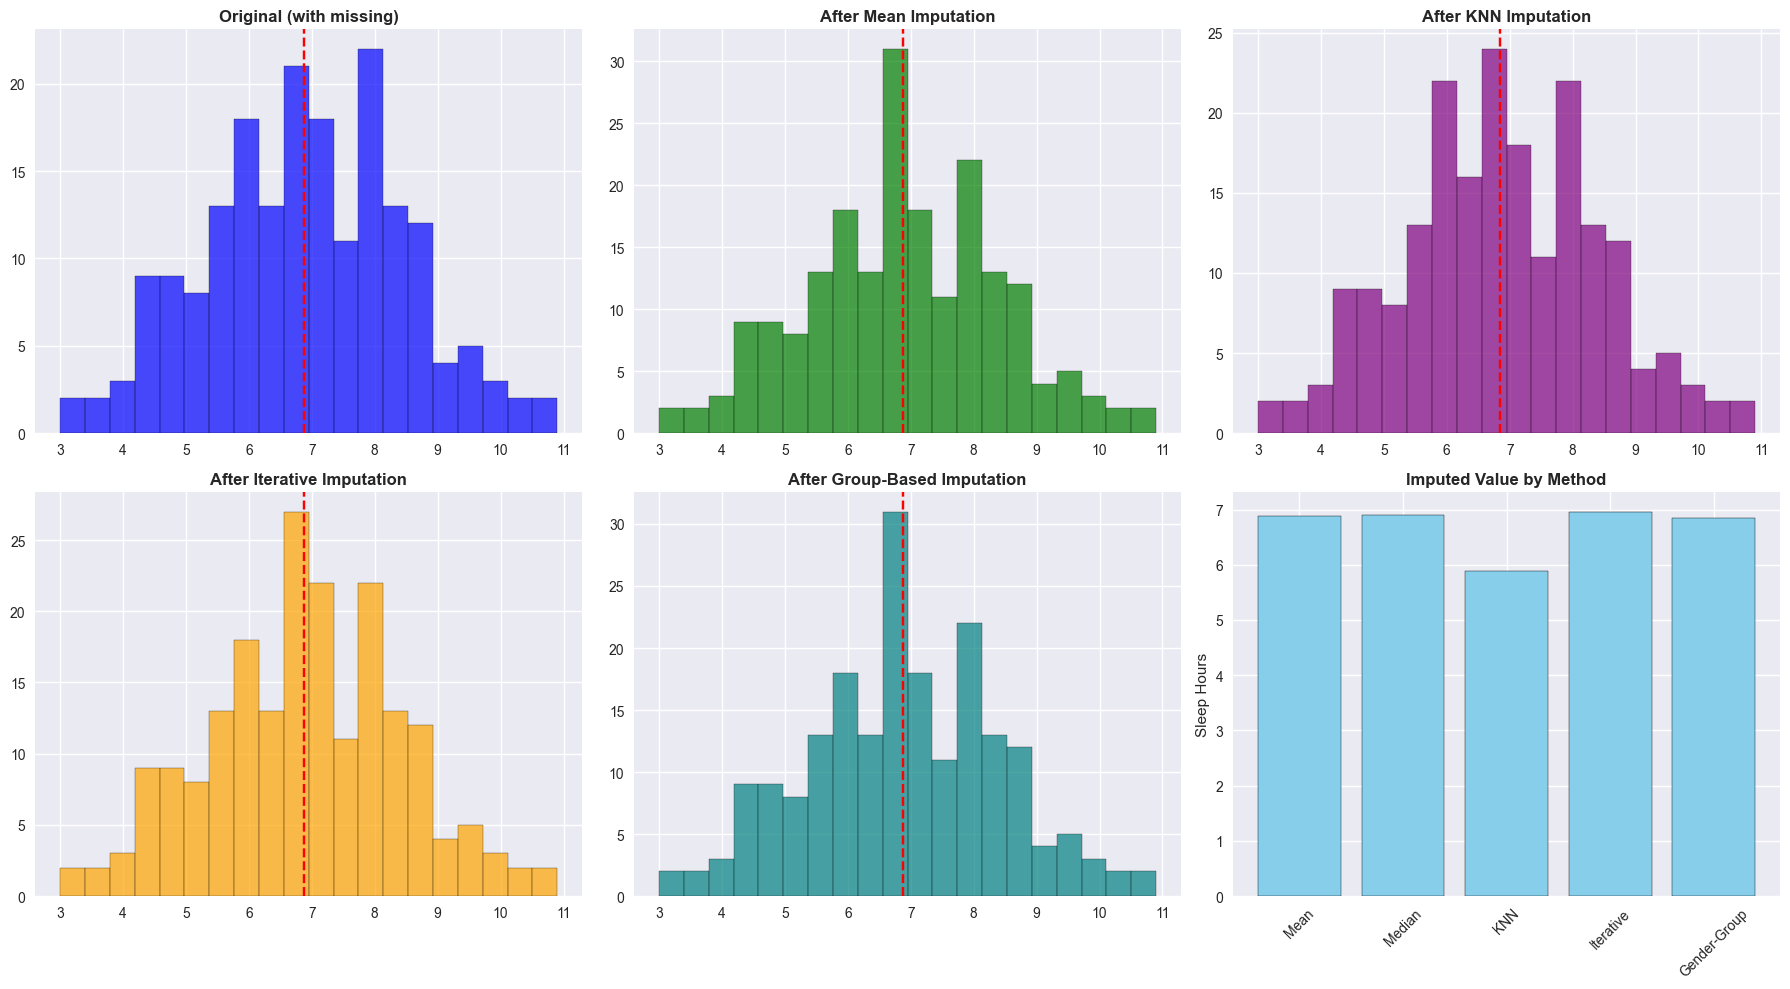


📈 OBSERVATIONS:
- Mean imputation creates a spike at the mean value
- KNN and Iterative preserve the distribution better
- Group-based adds domain knowledge
- Different methods give different results - choose wisely!


In [9]:
# 📊 COMPARING ALL METHODS

print("=== METHOD COMPARISON DEMONSTRATION ===\n")

# Create a comparison of imputed values for the first missing sleep entry
missing_idx = df[df['sleep_hours'].isnull()].index[0]
original_value = df.loc[missing_idx, 'sleep_hours']

print(f"Analyzing index {missing_idx} (original value: {original_value}):\n")

methods = {
    'Mean': df_stat.loc[missing_idx, 'sleep_hours_mean'],
    'Median': df_stat['sleep_hours'].median(),
    'KNN': df_knn.loc[missing_idx, 'sleep_hours'],
    'Iterative': df_iterative.loc[missing_idx, 'sleep_hours'],
    'Gender-Group': df_domain.loc[missing_idx, 'sleep_by_gender']
}

comparison_df = pd.DataFrame(list(methods.items()), columns=['Method', 'Imputed_Value'])
comparison_df['Difference_from_Mean'] = comparison_df['Imputed_Value'] - df['sleep_hours'].mean()

print("Imputed Values Comparison:")
print(comparison_df.round(2))
print()

# Visualize distributions after different imputations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Original
axes[0].hist(df['sleep_hours'].dropna(), bins=20, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Original (with missing)', fontweight='bold')
axes[0].axvline(df['sleep_hours'].mean(), color='red', linestyle='--', label='Mean')

# Mean imputation
axes[1].hist(df_stat['sleep_hours_mean'], bins=20, color='green', alpha=0.7, edgecolor='black')
axes[1].set_title('After Mean Imputation', fontweight='bold')
axes[1].axvline(df['sleep_hours'].mean(), color='red', linestyle='--')

# KNN imputation
axes[2].hist(df_knn['sleep_hours'], bins=20, color='purple', alpha=0.7, edgecolor='black')
axes[2].set_title('After KNN Imputation', fontweight='bold')
axes[2].axvline(df_knn['sleep_hours'].mean(), color='red', linestyle='--')

# Iterative imputation
axes[3].hist(df_iterative['sleep_hours'], bins=20, color='orange', alpha=0.7, edgecolor='black')
axes[3].set_title('After Iterative Imputation', fontweight='bold')
axes[3].axvline(df_iterative['sleep_hours'].mean(), color='red', linestyle='--')

# Group-based
axes[4].hist(df_domain['sleep_by_gender'], bins=20, color='teal', alpha=0.7, edgecolor='black')
axes[4].set_title('After Group-Based Imputation', fontweight='bold')
axes[4].axvline(df_domain['sleep_by_gender'].mean(), color='red', linestyle='--')

# Method comparison bar chart
axes[5].bar(comparison_df['Method'], comparison_df['Imputed_Value'], color='skyblue', edgecolor='black')
axes[5].set_title('Imputed Value by Method', fontweight='bold')
axes[5].tick_params(axis='x', rotation=45)
axes[5].set_ylabel('Sleep Hours')

plt.tight_layout()
plt.show()

print("\n📈 OBSERVATIONS:")
print("- Mean imputation creates a spike at the mean value")
print("- KNN and Iterative preserve the distribution better")
print("- Group-based adds domain knowledge")
print("- Different methods give different results - choose wisely!")

In [10]:
# 🔧 COMPLETE REUSABLE WORKFLOW FUNCTION

def handle_missing_values(df, strategy='auto', target_col=None, verbose=True):
    """
    Complete missing value handler for beginners!
    
    Parameters:
    -----------
    df : pandas DataFrame
        Input dataset with missing values
    strategy : str
        'auto' - Automatically choose best method
        'drop' - Drop rows with missing values
        'mean' - Mean imputation for numeric, mode for categorical
        'median' - Median imputation for numeric, mode for categorical
        'knn' - KNN imputation
        'iterative' - Iterative/MICE imputation
    target_col : str, optional
        Target variable name (to avoid imputing it)
    verbose : bool
        Print detailed information
    
    Returns:
    --------
    df_clean : pandas DataFrame
        Dataset with handled missing values
    report : dict
        Summary of actions taken
    """
    
    df_clean = df.copy()
    report = {'original_shape': df_clean.shape, 'actions': []}
    
    # Step 1: Analyze missingness
    missing_before = df_clean.isnull().sum().sum()
    if missing_before == 0:
        if verbose:
            print("✅ No missing values found!")
        return df_clean, report
    
    if verbose:
        print(f"🔍 Found {missing_before} missing values in {df_clean.isnull().any().sum()} columns")
    
    # Step 2: Separate numeric and categorical
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if target_col and target_col in numeric_cols:
        numeric_cols.remove(target_col)
    if target_col and target_col in categorical_cols:
        categorical_cols.remove(target_col)
    
    # Step 3: Apply strategy
    if strategy == 'drop':
        df_clean = df_clean.dropna()
        report['actions'].append(f"Dropped rows: {report['original_shape'][0] - len(df_clean)}")
        
    elif strategy in ['mean', 'median']:
        # Numeric columns
        for col in numeric_cols:
            if df_clean[col].isnull().any():
                value = df_clean[col].mean() if strategy == 'mean' else df_clean[col].median()
                df_clean[col] = df_clean[col].fillna(value)
                report['actions'].append(f"{col}: filled with {strategy}={value:.2f}")
        
        # Categorical columns
        for col in categorical_cols:
            if df_clean[col].isnull().any():
                mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Unknown'
                df_clean[col] = df_clean[col].fillna(mode_val)
                report['actions'].append(f"{col}: filled with mode={mode_val}")
                
    elif strategy == 'knn':
        # Only for numeric
        if numeric_cols:
            imputer = KNNImputer(n_neighbors=5)
            df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])
            report['actions'].append(f"Applied KNN imputation to {len(numeric_cols)} numeric columns")
        
        # Fill categorical with mode
        for col in categorical_cols:
            if df_clean[col].isnull().any():
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
                
    elif strategy == 'iterative':
        if numeric_cols:
            imputer = IterativeImputer(random_state=42)
            df_clean[numeric_cols] = imputer.fit_transform(df_clean[numeric_cols])
            report['actions'].append(f"Applied Iterative imputation to {len(numeric_cols)} numeric columns")
        
        for col in categorical_cols:
            if df_clean[col].isnull().any():
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    
    elif strategy == 'auto':
        # Smart selection based on missing %
        missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
        
        for col in df_clean.columns:
            if missing_pct[col] == 0:
                continue
            elif missing_pct[col] > 50:
                df_clean = df_clean.drop(columns=[col])
                report['actions'].append(f"{col}: dropped (>50% missing)")
            elif df_clean[col].dtype in ['object', 'category']:
                df_clean[col] = df_clean[col].fillna('Unknown')
                report['actions'].append(f"{col}: filled with 'Unknown'")
            elif missing_pct[col] < 5:
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
                report['actions'].append(f"{col}: filled with median")
            else:
                # Use KNN for moderate missing numeric data
                imputer = KNNImputer(n_neighbors=5)
                df_clean[[col]] = imputer.fit_transform(df_clean[[col]])
                report['actions'].append(f"{col}: filled with KNN")
    
    # Final report
    missing_after = df_clean.isnull().sum().sum()
    report['missing_before'] = missing_before
    report['missing_after'] = missing_after
    report['final_shape'] = df_clean.shape
    
    if verbose:
        print(f"\n✅ Complete! Missing values: {missing_before} → {missing_after}")
        print(f"   Final dataset shape: {report['final_shape']}")
    
    return df_clean, report

# Test the function
print("Testing the complete workflow function:\n")
df_result, report = handle_missing_values(df, strategy='auto')
print("\nDetailed Report:")
for action in report['actions']:
    print(f"  • {action}")

Testing the complete workflow function:

🔍 Found 96 missing values in 5 columns

✅ Complete! Missing values: 96 → 0
   Final dataset shape: (200, 10)

Detailed Report:
  • daily_screen_time_min: filled with median
  • social_media_time_min: filled with median
  • sleep_hours: filled with KNN
  • physical_activity_min: filled with KNN
  • anxiety_level: filled with KNN


## 🛡️ How to PREVENT Missing Values (Best Practices)

### 📝 Data Collection Phase:
1. **Mandatory Fields**: Make critical fields required in forms
2. **Data Validation**: Use dropdowns, date pickers, range validators
3. **Clear Instructions**: Explain why data is needed and how it will be used
4. **Progressive Disclosure**: Ask sensitive questions later in the survey
5. **Test Equipment**: Calibrate sensors, check connections regularly

### 🔧 Data Processing Phase:
1. **Standardize Missing Codes**: Use NaN consistently, avoid mixing `-999`, `?`, `N/A`
2. **Audit Trail**: Keep original data, document all transformations
3. **Automated Checks**: Set up alerts when missing % exceeds threshold
4. **Cross-Validation**: Compare with external sources when possible

### 🤖 ML Pipeline Best Practices:
1. **Separate Train/Test Imputation**: NEVER fit imputer on test data!
   ```python
   # CORRECT
   imputer.fit(X_train)
   X_train_imputed = imputer.transform(X_train)
   X_test_imputed = imputer.transform(X_test)  # Only transform!
   ```

2. **Imputation as Feature**: Add missing indicator as new feature
3. **Multiple Imputation**: Run analysis multiple times with different imputations
4. **Sensitivity Analysis**: Test if results change with different strategies

### ✅ Decision Tree: Which Strategy to Use?

```
Is missing % > 50%?
├── YES → Drop column (unless critical)
└── NO → Is it MCAR?
    ├── YES → Listwise deletion OK if <5% missing
    └── NO → Is it MAR?
        ├── YES → Use KNN or Iterative imputation
        └── NO (MNAR) → Use domain knowledge, sensitivity analysis
```

### 📋 Checklist Before Choosing Strategy:
- [ ] Analyzed missingness pattern (MCAR/MAR/MNAR)
- [ ] Checked correlation between missing values
- [ ] Considered business context
- [ ] Evaluated impact on distribution
- [ ] Documented your choice
- [ ] Validated on hold-out set

=== IMPACT ON MACHINE LEARNING MODEL ===

Model Performance Comparison:
                Strategy  Sample_Size  R2_Score    RMSE
0  Original (Dropped NA)          120   -0.1857  2.4242
1        Mean Imputation          200    0.5724  1.8535
2      Median Imputation          200    0.4049  2.1866
3         KNN Imputation          200    0.2067  2.5246
4   Iterative Imputation          200    0.5818  1.8329


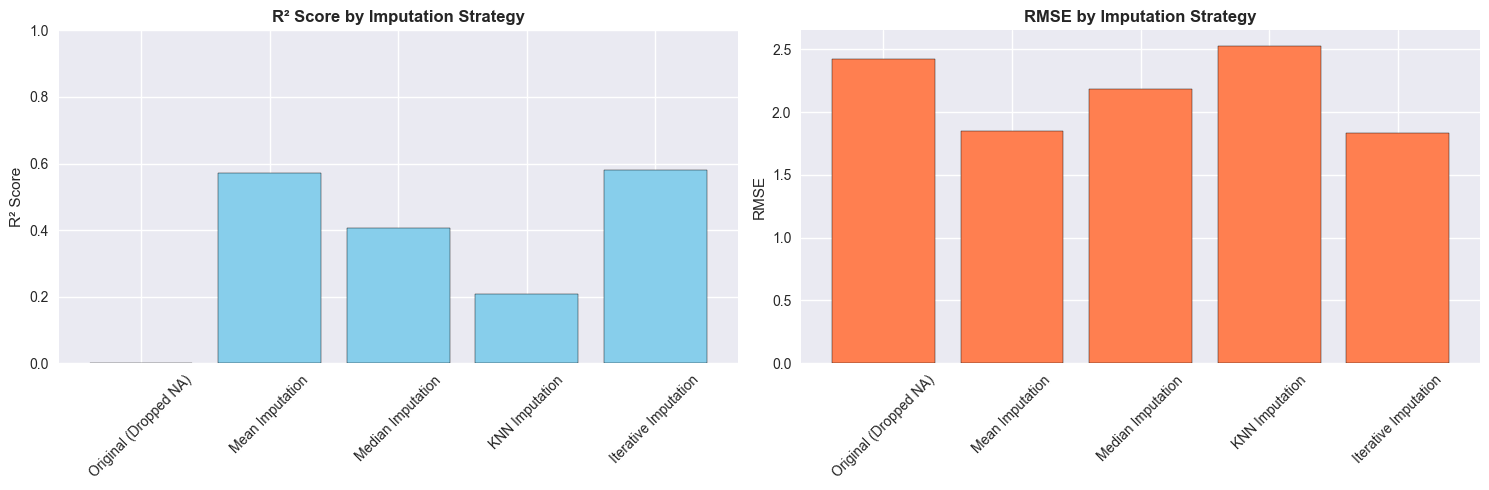


💡 KEY TAKEAWAYS:
1. Different strategies yield different model performance
2. More data (from imputation) ≠ Better performance (if imputation is wrong)
3. Advanced methods (KNN, Iterative) often perform better but not always
4. Always validate on unseen data!


In [11]:
# 🎯 REAL MACHINE LEARNING EXAMPLE

print("=== IMPACT ON MACHINE LEARNING MODEL ===\n")

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Prepare data
features = ['age', 'daily_screen_time_min', 'social_media_time_min', 
           'sleep_hours', 'physical_activity_min', 'anxiety_level']
target = 'stress_level'

# Create different versions
strategies = {
    'Original (Dropped NA)': df.dropna(),
    'Mean Imputation': df.copy(),
    'Median Imputation': df.copy(),
    'KNN Imputation': df.copy(),
    'Iterative Imputation': df.copy()
}

# Apply imputations
for col in features:
    if col == 'sleep_hours':
        strategies['Mean Imputation'][col] = strategies['Mean Imputation'][col].fillna(df[col].mean())
        strategies['Median Imputation'][col] = strategies['Median Imputation'][col].fillna(df[col].median())
    elif col == 'physical_activity_min':
        strategies['Mean Imputation'][col] = strategies['Mean Imputation'][col].fillna(df[col].mean())
        strategies['Median Imputation'][col] = strategies['Median Imputation'][col].fillna(df[col].median())
    elif col == 'anxiety_level':
        strategies['Mean Imputation'][col] = strategies['Mean Imputation'][col].fillna(df[col].mean())
        strategies['Median Imputation'][col] = strategies['Median Imputation'][col].fillna(df[col].median())

# KNN and Iterative
imputer_knn = KNNImputer(n_neighbors=5)
imputer_iter = IterativeImputer(random_state=42)

strategies['KNN Imputation'][features] = imputer_knn.fit_transform(strategies['KNN Imputation'][features])
strategies['Iterative Imputation'][features] = imputer_iter.fit_transform(strategies['Iterative Imputation'][features])

# Train and evaluate models
results = []

for name, data in strategies.items():
    # Prepare data
    X = data[features]
    y = data[target]
    
    # Remove any remaining NA in target
    mask = y.notna()
    X, y = X[mask], y[mask]
    
    if len(X) < 10:
        continue
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        'Strategy': name,
        'Sample_Size': len(X),
        'R2_Score': r2,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results)
print("Model Performance Comparison:")
print(results_df.round(4))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(results_df['Strategy'], results_df['R2_Score'], color='skyblue', edgecolor='black')
axes[0].set_title('R² Score by Imputation Strategy', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 1)

axes[1].bar(results_df['Strategy'], results_df['RMSE'], color='coral', edgecolor='black')
axes[1].set_title('RMSE by Imputation Strategy', fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 KEY TAKEAWAYS:")
print("1. Different strategies yield different model performance")
print("2. More data (from imputation) ≠ Better performance (if imputation is wrong)")
print("3. Advanced methods (KNN, Iterative) often perform better but not always")
print("4. Always validate on unseen data!")

## 🎓 Summary & Quick Reference Cheat Sheet

### 🧠 Core Concepts Remember:

| Concept | Key Point |
|---------|-----------|
| **MCAR** | Missing randomly, least problematic |
| **MAR** | Missing relates to observed data, fixable |
| **MNAR** | Missing relates to missing value itself, tricky |
| **Bias** | Wrong imputation → wrong conclusions |
| **Variance** | Mean imputation reduces variance artificially |

### 🛠️ Strategy Selection Guide:

| Scenario | Recommended Strategy | Code |
|----------|---------------------|------|
| <5% missing, MCAR | Listwise deletion | `df.dropna()` |
| Normal distribution | Mean imputation | `df.fillna(df.mean())` |
| Skewed/outliers | Median imputation | `df.fillna(df.median())` |
| Categorical | Mode imputation | `df.fillna(df.mode()[0])` |
| Complex relationships | KNN imputation | `KNNImputer(n_neighbors=5)` |
| High-dimensional | Iterative imputation | `IterativeImputer()` |
| Time series | Forward/backward fill | `df.fillna(method='ffill')` |
| >50% missing | Drop column | `df.drop(columns=['col'])` |

### 🚨 Common Mistakes to Avoid:

1. ❌ **Imputing before train/test split** → Data leakage!
2. ❌ **Ignoring missingness patterns** → Biased results
3. ❌ **Using mean for categorical data** → Nonsense values
4. ❌ **Not documenting imputation** → Irreproducible research
5. ❌ **Assuming MCAR without testing** → Wrong method selection
6. ❌ **Imputing target variable** → Cheating!

### ✅ Best Practices Checklist:

- [ ] Always explore missingness pattern first
- [ ] Visualize missing data with heatmaps
- [ ] Consider business context
- [ ] Try multiple strategies, compare results
- [ ] Use missing indicators as features
- [ ] Document everything in data dictionary
- [ ] Validate on hold-out set
- [ ] Report limitations in final analysis

### 📚 Further Learning Resources:

1. **Little & Rubin (2019)**: Statistical Analysis with Missing Data (The Bible)
2. **Scikit-learn Imputation**: https://scikit-learn.org/stable/modules/impute.html
3. **Pandas Documentation**: https://pandas.pydata.org/docs/user_guide/missing_data.html
4. **Missingno Library**: Visualize missing data patterns

---

## 🎉 Congratulations!

You now have a comprehensive understanding of missing values in data science!

**Remember**: There's no "perfect" way to handle missing data. The best method depends on:
- Why the data is missing
- How much is missing
- Your analysis goals
- Domain knowledge

**When in doubt**: Sensitivity analysis (try multiple methods and see if results change)!

**Happy Data Wrangling! 🐼✨**

## 🏋️ Practice Exercise

Try this on your own dataset or create a new one:

### Exercise 1: Detection
```python
# Load your dataset
df = pd.read_csv('your_data.csv')

# 1. What % of each column is missing?
# 2. Is the missing data MCAR, MAR, or MNAR? How can you tell?
# 3. Visualize the missing pattern
```

### Exercise 2: Strategy Implementation
```python
# Try 3 different imputation strategies
# Compare their impact on feature distributions
# Which one makes most sense for your data?
```

### Exercise 3: ML Impact
```python
# Build a simple model with each strategy
# Compare R² scores or accuracy
# Does better imputation lead to better predictions?
```

### Challenge: Missing Indicator Feature
```python
# Create a binary feature indicating if 'income' was imputed
# Does this improve your model? (Hint: It often does!)
```